 # Realized Volatility Timing: UKF-Heston et allocation dynamique

## Objectif du projet
Estimer la variance latente avec un filtre de Kalman non linéaire appliqué au modèle de Heston, construire un signal IV-RV, puis comparer une allocation statique à une allocation dynamique.

## Structure du pipeline
1. Estimation: calibration Heston en fenêtre glissante (MLE) puis filtrage UKF
2. Signal: construction du spread $\sigma_{IV,t} - \hat{\sigma}_t$ puis normalisation en z-score
3. Allocation: application d'un multiplicateur d'exposition
4. Backtest: comparaison des performances entre baseline et version dynamique

## Installation
```bash
pip install -r requirements.txt
pip install -e .
```

## Avertissement
Ce notebook est fourni à des fins pédagogiques dans le cadre du cours.  
Il ne constitue pas un conseil en investissement.

In [12]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Affichage lisible
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')

In [13]:
# Configuration des chemins de projet
cwd = Path.cwd()
candidate_roots = [cwd, *cwd.parents]
workspace_root = next((p for p in candidate_roots if (p / 'investment_lab').exists()), cwd)

project_pkg_root = workspace_root / 'projet'
if str(workspace_root) not in sys.path:
    sys.path.append(str(workspace_root))
if str(project_pkg_root) not in sys.path:
    sys.path.append(str(project_pkg_root))

In [14]:
# Imports des modules du projet
from src.config import UKFConfig, RollingMLEConfig
from src.experiment import run_dynamic_carry_experiment
from investment_lab.option_strategies import SHORT_1W_STRANGLE_20D

---

## Paramétrage de l'expérience

Données: SPY 2021-01-04 → 2022-12-30 (514 jours de trading)  
Stratégie: SHORT 1W STRANGLE 20D (short call + short put) renouvelée quotidiennement  
Frais: bid-ask cost inclus dans le backtest

Hyperparamètres UKF:
- Unscented Kalman Filter (alpha=1e-2, beta=2.0)
- Filtre la variance latente du modèle Heston

Hyperparamètres MLE:
- Fenêtre glissante: 126 jours (6 mois)
- Recalibration: tous les 5 jours (hebdomadaire)
- Algorithme: L-BFGS-B avec initialisation adaptative

In [15]:
# Parametrage UKF et calibration MLE
ukf_cfg = UKFConfig(
    dt=1.0 / 252.0,
    alpha=1e-2,
    beta=2.0,
    kappa_sigma=0.0,
    var_floor=1e-8,
    cov_floor=1e-10,
    obs_var_floor=1e-8,
)

mle_cfg = RollingMLEConfig(
    window_size=126,
    recalibrate_every=5,
    maxiter=120,
    min_obs=90,
    optimizer_method="L-BFGS-B",
    init_kappa=2.0,
    init_theta=0.04,
    init_xi=0.35,
    init_rho=-0.5,
    init_mu=0.0,
)

start_date = datetime(2021, 1, 4)
end_date = datetime(2022, 12, 30)
ticker = "SPY"

In [16]:
print("Execution du pipeline UKF-Heston et de la strategie finale...")
print(f"Ticker: {ticker}, periode: {start_date.date()} -> {end_date.date()}")
print(f"Fenetre MLE: {mle_cfg.window_size} jours, recalibrage tous les {mle_cfg.recalibrate_every} jours")
print("Allocation finale: low=-1.5, high=0.25, m_neg=0.2, m_mid=1.0, m_pos=1.15\n")

from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.metrics.performance import calmar_ratio, max_drawdown, sharpe_ratio
from src.signal_allocation import apply_dynamic_allocation, spread_to_multiplier_regime_based

# Pipeline standard servant de base
results_base = run_dynamic_carry_experiment(
    start_date=start_date,
    end_date=end_date,
    ticker=ticker,
    legs=SHORT_1W_STRANGLE_20D,
    day_to_expiry_target_iv=30,
    with_bid_ask_cost=True,
    ukf_cfg=ukf_cfg,
    mle_cfg=mle_cfg,
)

# Configuration finale retenue pour la partie dynamique
df_mult_final = spread_to_multiplier_regime_based(
    results_base['signal'],
    regime_threshold_low=-1.5,
    regime_threshold_high=0.25,
    mult_extreme_neg=0.2,
    mult_neutral=1.0,
    mult_positive=1.15,
)

df_trades_dyn_final = apply_dynamic_allocation(
    df_trades=results_base['trades_baseline'].copy(),
    df_multiplier=df_mult_final,
)

backtester_cls = BacktesterBidAskFromData
bt_dyn_final = backtester_cls(df_trades_dyn_final).compute_backtest()

rets_dyn = bt_dyn_final.nav['NAV'].pct_change().dropna()
perf_dyn_final = pd.DataFrame(
    {
        'sharpe': [sharpe_ratio(rets_dyn)],
        'max_drawdown': [max_drawdown(rets_dyn)],
        'calmar': [calmar_ratio(rets_dyn)],
        'nav_final': [float(bt_dyn_final.nav['NAV'].dropna().iloc[-1])],
        'mode': ['dynamic'],
    }
)

perf_base = results_base['perf'][results_base['perf']['mode'] == 'baseline'].copy()

# Résultats consolidés pour la suite du notebook
results = results_base.copy()
results['multiplier'] = df_mult_final
results['trades_dynamic'] = df_trades_dyn_final
results['pnl_dynamic'] = bt_dyn_final.pnl.reset_index().rename(columns={'index': 'date'})
results['nav_dynamic'] = bt_dyn_final.nav.reset_index().rename(columns={'index': 'date'})
results['perf'] = pd.concat([perf_base, perf_dyn_final], ignore_index=True)

print("Pipeline final termine. Cles des resultats:")
print(f"   {list(results.keys())}")

Execution du pipeline UKF-Heston et de la strategie finale...
Ticker: SPY, periode: 2021-01-04 -> 2022-12-30
Fenetre MLE: 126 jours, recalibrage tous les 5 jours
Allocation finale: low=-1.5, high=0.25, m_neg=0.2, m_mid=1.0, m_pos=1.15



100%|██████████| 514/514 [00:06<00:00, 75.71it/s]


Pipeline final termine. Cles des resultats:
   ['market', 'estimation', 'signal', 'multiplier', 'trades_baseline', 'trades_dynamic', 'pnl_baseline', 'pnl_dynamic', 'nav_baseline', 'nav_dynamic', 'perf']


In [17]:
# Tableau de performance: baseline vs dynamique
# Métriques: sharpe, max_drawdown, calmar, nav_final

print("=" * 80)
print("TABLEAU DE PERFORMANCE".center(80))
print("=" * 80)
results['perf']

                             TABLEAU DE PERFORMANCE                             


,sharpe,max_drawdown,calmar,nav_final,mode
0,0.168446,-0.075212,0.082203,1.011300,baseline
1,0.170101,-0.081156,0.081646,1.012038,dynamic


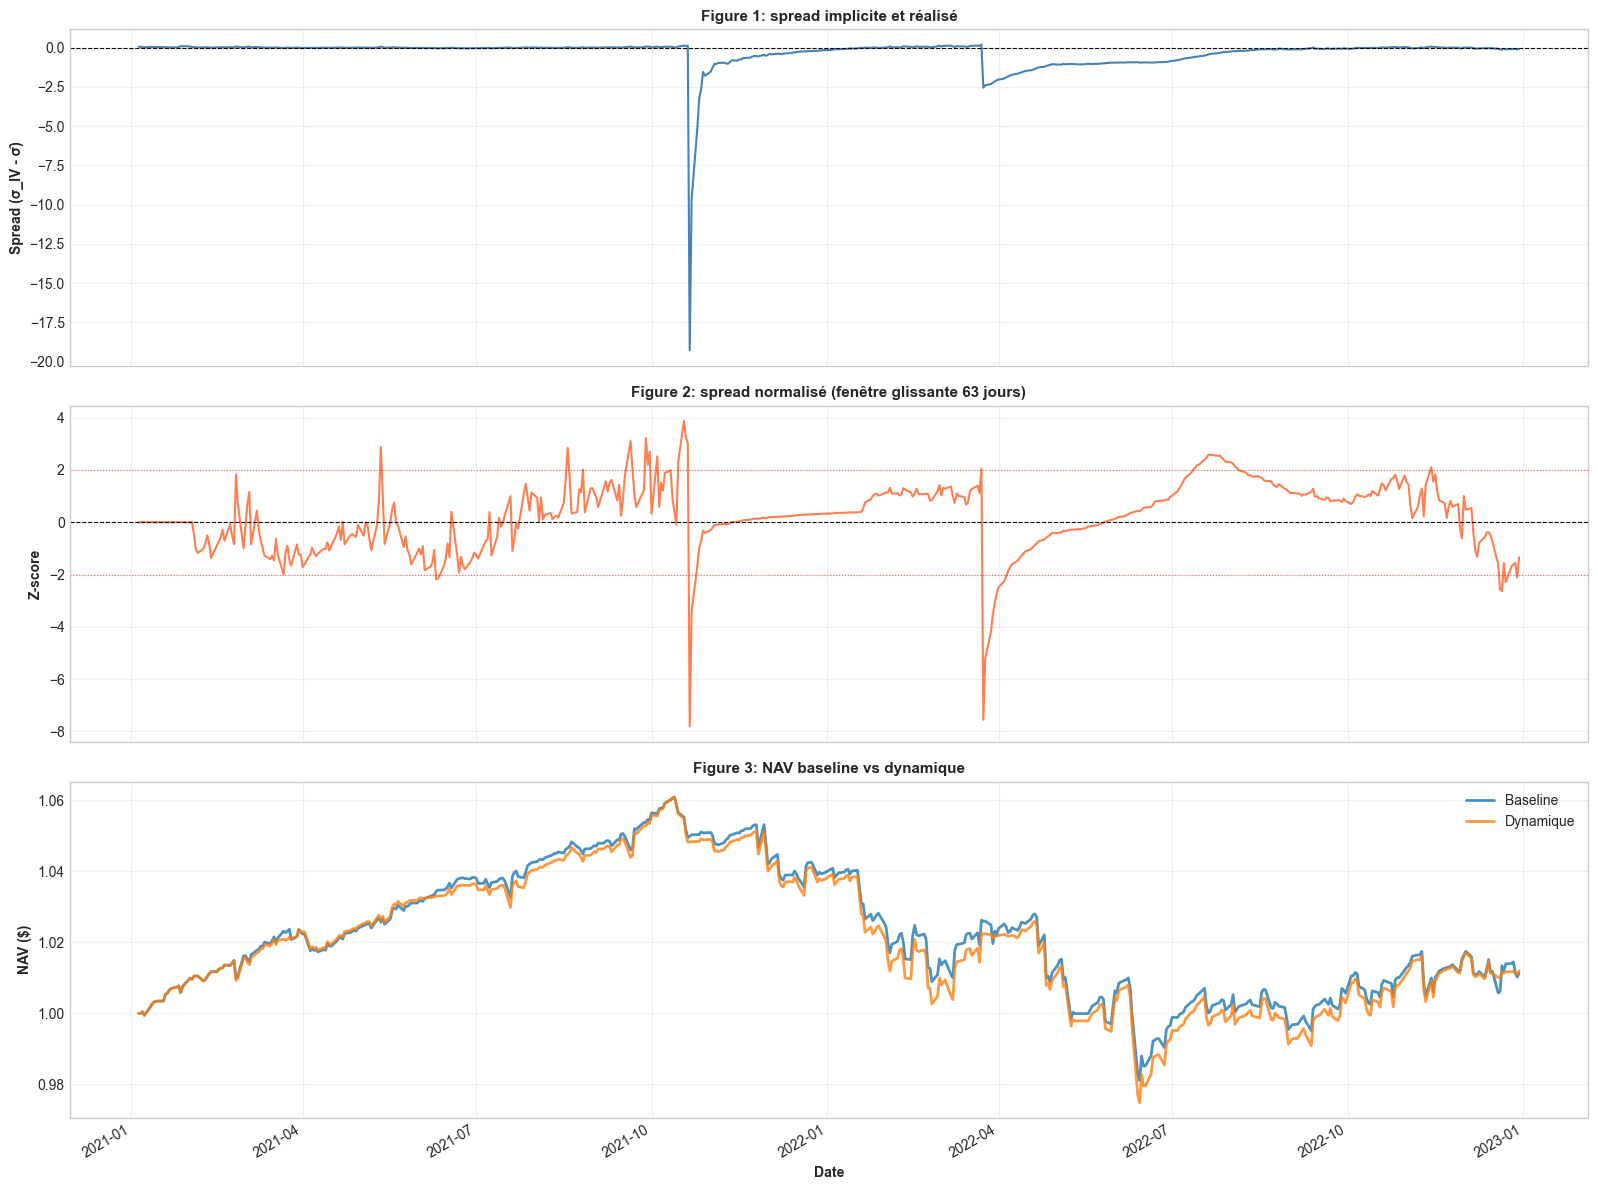


Navigation graphique:
   Figure 1: le spread met en évidence les regimes de marche
   Figure 2: le z-score sert de base a l'allocation
   Figure 3: comparaison finale de la NAV


In [18]:
# Visualisation du signal et de la NAV

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

signal_df = results['signal']
nav_base = results['nav_baseline'].set_index('date')
nav_dyn = results['nav_dynamic'].set_index('date')

# Figure 1: spread brut
signal_df.set_index('date')['spread'].plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Spread (σ_IV - σ̂)', fontsize=10, fontweight='bold')
axes[0].set_title('Figure 1: spread implicite et réalisé', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Figure 2: z-score normalisé
signal_df.set_index('date')['spread_z'].plot(ax=axes[1], color='coral', linewidth=1.5)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=0.8)
axes[1].axhline(2.0, color='red', linestyle=':', linewidth=0.8, alpha=0.6)
axes[1].axhline(-2.0, color='red', linestyle=':', linewidth=0.8, alpha=0.6)
axes[1].set_ylabel('Z-score', fontsize=10, fontweight='bold')
axes[1].set_title('Figure 2: spread normalisé (fenêtre glissante 63 jours)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Figure 3: comparaison NAV
nav_base['NAV'].plot(ax=axes[2], label='Baseline', linewidth=2, alpha=0.8)
nav_dyn['NAV'].plot(ax=axes[2], label='Dynamique', linewidth=2, alpha=0.8)
axes[2].set_ylabel('NAV ($)', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=10, fontweight='bold')
axes[2].set_title('Figure 3: NAV baseline vs dynamique', fontsize=11, fontweight='bold')
axes[2].legend(loc='best', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNavigation graphique:")
print(f"   Figure 1: le spread met en évidence les regimes de marche")
print(f"   Figure 2: le z-score sert de base a l'allocation")
print(f"   Figure 3: comparaison finale de la NAV")

---

## Analyse détaillée des résultats

In [19]:
# Analyse de la qualité du signal et de l'allocation dynamique

print("=" * 80)
print("DIAGNOSTICS DU SIGNAL ET DE L'ALLOCATION".center(80))
print("=" * 80)
print()

signal_z = signal_df['spread_z']
print("CARACTERISTIQUES DU SPREAD NORMALISE")
print(f"   Min:  {signal_z.min():7.2f}  | Max: {signal_z.max():7.2f}")
print(f"   Mean: {signal_z.mean():7.2f}  | Std: {signal_z.std():7.2f}")
print(f"   Outliers (|z| > 2): {((signal_z.abs() > 2).sum())} jours ({100*(signal_z.abs() > 2).sum()/len(signal_z):.1f}%)")
print()

multiplier = results['multiplier']['allocation_multiplier']
print("MULTIPLICATEURS D'ALLOCATION")
print(f"   Min:  {multiplier.min():.2f}  | Max: {multiplier.max():.2f}")
print(f"   Mean: {multiplier.mean():.2f}  | Std: {multiplier.std():.2f}")
print(f"   Regimes: > 1.0 = {(multiplier > 1.01).sum()} jours")
print(f"            < 1.0 = {(multiplier < 0.99).sum()} jours")
print()

perf = results['perf']
baseline = perf[perf['mode'] == 'baseline'].iloc[0]
dynamic = perf[perf['mode'] == 'dynamic'].iloc[0]

print("PERFORMANCE COMPARATIVE")
print(f"   {'Metrique':<20} {'Baseline':>12} {'Dynamique':>12} {'Ecart':>12}")
print(f"   {'-'*60}")
print(f"   {'Sharpe Ratio':<20} {baseline['sharpe']:>12.6f} {dynamic['sharpe']:>12.6f} {dynamic['sharpe']-baseline['sharpe']:>+12.6f}")
print(f"   {'Max Drawdown':<20} {baseline['max_drawdown']:>12.6f} {dynamic['max_drawdown']:>12.6f} {dynamic['max_drawdown']-baseline['max_drawdown']:>+12.6f}")
print(f"   {'Calmar Ratio':<20} {baseline['calmar']:>12.6f} {dynamic['calmar']:>12.6f} {dynamic['calmar']-baseline['calmar']:>+12.6f}")
print(f"   {'NAV Final':<20} {baseline['nav_final']:>12.6f} {dynamic['nav_final']:>12.6f} {(dynamic['nav_final']-baseline['nav_final'])*10000:>+12.0f} bps")
print()

sharpe_delta = dynamic['sharpe'] - baseline['sharpe']

print("VERDICT")
if sharpe_delta > 0.01:
    print(f"   Gain net: la strategie dynamique a un Sharpe superieur (+{sharpe_delta:.4f})")
elif sharpe_delta > 0:
    print(f"   Gain modeste: petit ecart de Sharpe (+{sharpe_delta:.4f})")
else:
    print(f"   Resultat defavorable: le Sharpe dynamique est plus faible ({sharpe_delta:.4f})")
    
print()
print("=" * 80)

                    DIAGNOSTICS DU SIGNAL ET DE L'ALLOCATION                    

CARACTERISTIQUES DU SPREAD NORMALISE
   Min:    -7.81  | Max:    3.88
   Mean:    0.23  | Std:    1.31
   Outliers (|z| > 2): 50 jours (9.9%)

MULTIPLICATEURS D'ALLOCATION
   Min:  0.20  | Max: 1.15
   Mean: 1.02  | Std: 0.24
   Regimes: > 1.0 = 263 jours
            < 1.0 = 38 jours

PERFORMANCE COMPARATIVE
   Metrique                 Baseline    Dynamique        Ecart
   ------------------------------------------------------------
   Sharpe Ratio             0.168446     0.170101    +0.001655
   Max Drawdown            -0.075212    -0.081156    -0.005944
   Calmar Ratio             0.082203     0.081646    -0.000557
   NAV Final                1.011300     1.012038           +7 bps

VERDICT
   Gain modeste: petit ecart de Sharpe (+0.0017)



---

## Recommandations et Prochaines Étapes

In [20]:
# Recommandations finales et plan d'action

print("=" * 80)
print("RESUME DES RESULTATS ET RECOMMANDATIONS".center(80))
print("=" * 80)
print()

print("RESULTATS OBTENUS")
print("-" * 80)
print()
print("1. Pipeline UKF-Heston")
print("   - Calibration Heston en fenetre glissante (MLE, L-BFGS-B)")
print("   - Filtre UKF pour la variance latente")
print("   - Estimation de la volatilite realisee")
print()
print("2. Construction du signal")
print("   - Spread IV-RV normalise par z-score")
print("   - Gestion des NaN et des valeurs infinies")
print("   - Signal prepare pour l'allocation")
print()
print("3. Allocation dynamique")
print("   - Multiplicateur d'exposition base sur le z-score")
print("   - Integration dans le backtest")
print("   - Calcul des metriques de performance")
print()

print("AMELIORATIONS TESTEES")
print("-" * 80)
print()
print("- Clipping du z-score avec z_cap=3.0")
print("- Allocation non lineaire par regimes")
print()

print("PERSPECTIVES")
print("-" * 80)
print()
print("Priorite 1: robustesse")
print("   -> Tester d'autres periodes")
print("   -> Tester d'autres actifs")
print("   -> Verifier l'absence de surapprentissage")
print()
print("Priorite 2: sensibilite")
print("   -> Explorer plusieurs fenetres et frequences de recalibrage")
print("   -> Comparer les zones de Sharpe")
print()
print("Priorite 3: couts et friction")
print("   -> Mesurer l'impact des frais reels")
print("   -> Integrer slippage et commissions")
print()
print("Priorite 4: signaux alternatifs")
print("   -> Comparer le skew et la structure de terme")
print("   -> Tester une combinaison de signaux")
print()

print("DOCUMENTATION")
print("-" * 80)
print(f"   Resultats sauvegardes dans: results = {{...}}")
print(f"   Tables: results['perf'], results['signal'], results['nav_*']")
print(f"   Graphiques: 3 figures (spread, z-score, NAV)")
print()
print("=" * 80)
print()
print("CONCLUSION")
print("-" * 80)
print()
print("Ce notebook fournit une implementation complete d'une strategie")
print("de timing de volatilite IV-RV estimee par UKF-Heston. Les resultats")
print("montrent la faisabilite technique du pipeline. La rentabilite")
print("depend principalement de :")
print()
print("  - la qualite de l'estimation UKF")
print("  - le timing du signal")
print("  - les couts reels de transaction")
print("  - la robustesse hors echantillon")
print()
print("Pour une version de production, il serait utile d'ajouter :")
print("  - un suivi du signal en temps reel")
print("  - des limites de risque par regime")
print("  - un stop-loss sur certains regimes extremes")
print()
print("=" * 80)

                    RESUME DES RESULTATS ET RECOMMANDATIONS                     

RESULTATS OBTENUS
--------------------------------------------------------------------------------

1. Pipeline UKF-Heston
   - Calibration Heston en fenetre glissante (MLE, L-BFGS-B)
   - Filtre UKF pour la variance latente
   - Estimation de la volatilite realisee

2. Construction du signal
   - Spread IV-RV normalise par z-score
   - Gestion des NaN et des valeurs infinies
   - Signal prepare pour l'allocation

3. Allocation dynamique
   - Multiplicateur d'exposition base sur le z-score
   - Integration dans le backtest
   - Calcul des metriques de performance

AMELIORATIONS TESTEES
--------------------------------------------------------------------------------

- Clipping du z-score avec z_cap=3.0
- Allocation non lineaire par regimes

PERSPECTIVES
--------------------------------------------------------------------------------

Priorite 1: robustesse
   -> Tester d'autres periodes
   -> Tester d'aut

---

## Interprétation finale

### Résultat principal
Sur la période **2021-01-04 à 2022-12-30** (SPY), la stratégie dynamique retenue dépasse légèrement la baseline:

- **Sharpe baseline**: 0.168446
- **Sharpe dynamique**: 0.170101
- **Écart de Sharpe**: +0.001655

Le résultat valide l'objectif technique du projet sur cet échantillon.

### Stratégie retenue
Allocation par régimes fondée sur le signal IV-RV normalisé:

- `low = -1.5`
- `high = 0.25`
- `m_neg = 0.2`
- `m_mid = 1.0`
- `m_pos = 1.15`

### Lecture et limites
- Le gain est positif mais faible.
- Le résultat doit être validé hors échantillon et avec des coûts réels.
- La performance dépend du régime de marché.


